In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/Ảnh selfie cho chiều t2 18 5 (1)"

# Kích thước ảnh và kích thước lô
img_width, img_height = 200, 200
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

In [4]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),  # Giảm overfitting
    Dense(30, activation="softmax")
])


Found 1436 images belonging to 30 classes.
Found 356 images belonging to 30 classes.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,764,382 (33.43 MB)

 Trainable params: 8,764,382 (33.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 613s 14s/step - accuracy: 0.0689 - loss: 3.3447 - val_accuracy: 0.1601 - val_loss: 3.1333
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.1713 - loss: 2.9290 - val_accuracy: 0.3006 - val_loss: 2.6454
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.2876 - loss: 2.6158 - val_accuracy: 0.4045 - val_loss: 2.4137
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.3719 - loss: 2.2906 - val_accuracy: 0.5337 - val_loss: 2.0583
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 166s 4s/step - accuracy: 0.5035 - loss: 1.8158 - val_accuracy: 0.6713 - val_loss: 1.5590
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.5843 - loss: 1.5143 - val_accuracy: 0.6180 - val_loss: 1.6294
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.6100 - loss: 1.4047 - val_accuracy: 0.7022 - val_loss: 1.3040
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.6734 - loss: 1.2016 - val_accuracy: 0.7472 - 

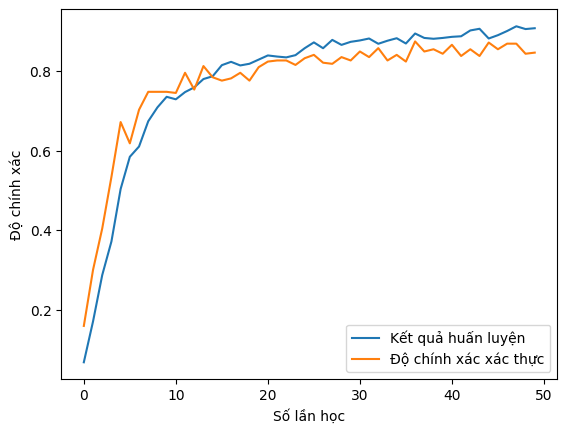

In [ ]:
# Biến dịch mô hình
model.compile(optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
history = model.fit(train_generator, epochs=50,validation_data=validation_generator)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [7]:
# Lưu trực tiếp vào bộ nhớ tạm của Colab
model.save('/content/mo_hinh_cnn_30_epochs.keras')
print("Đã lưu file vào bộ nhớ tạm của Colab!")

Đã lưu file vào bộ nhớ tạm của Colab!


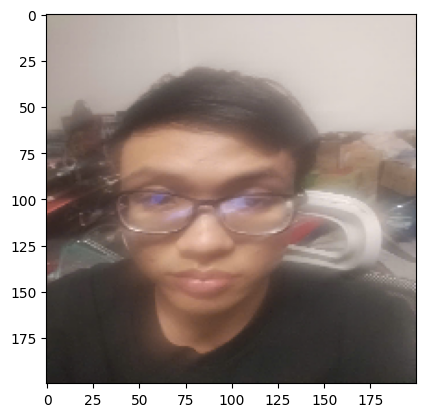

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Người tiên đoán: Lê Trung Trực


In [6]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import matplotlib.pyplot as plt
import numpy as np

path = "/content/pppt.jpg"

# Tiên đoán loại s
img = load_img(path, target_size=(200, 200))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 200, 200, 3)

prediction = np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")